In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
data_size= 200

temp = np.random.uniform(20, 40, data_size)
price = np.random.uniform(10, 25, data_size)
weekend = np.random.choice([0, 1], size=data_size, p=[0.7, 0.3])

sales = 100 + (temp * 10) + (price * -8) + (weekend * 50) + np.random.normal(0, 15, data_size)

# DataFrame oluşturma
df_multi = pd.DataFrame({
    'Temperature': temp,
    'Price': price,
    'Weekend': weekend,
    'Sales': sales
})

df_multi.head()

,Temperature,Price,Weekend,Sales
0,27.490802,19.630475,0,209.910362
1,39.014286,11.262099,1,438.152973
2,34.639879,12.424431,0,345.397887
3,31.973170,23.478313,1,266.376559
4,23.120373,19.096436,0,170.127501


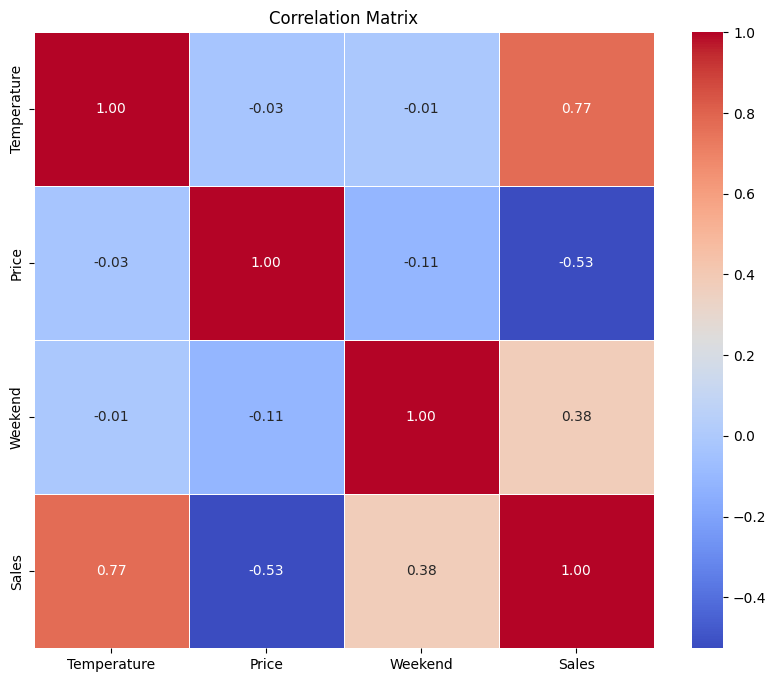

In [2]:
plt.figure(figsize=(10, 8))
corr_matrix = df_multi.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [3]:

X = df_multi[['Temperature', 'Price', 'Weekend']]

y = df_multi['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

print("Multiple Linear Regression Model Trained.")

Multiple Linear Regression Model Trained.


In [5]:
coefficients = pd.DataFrame(multi_model.coef_, X.columns, columns=['Coefficient (Effect)'])
print(f"Intercept: {multi_model.intercept_:.2f}")
print(coefficients)

Intercept: 103.34
             Coefficient (Effect)
Temperature              9.879499
Price                   -8.166534
Weekend                 56.753973


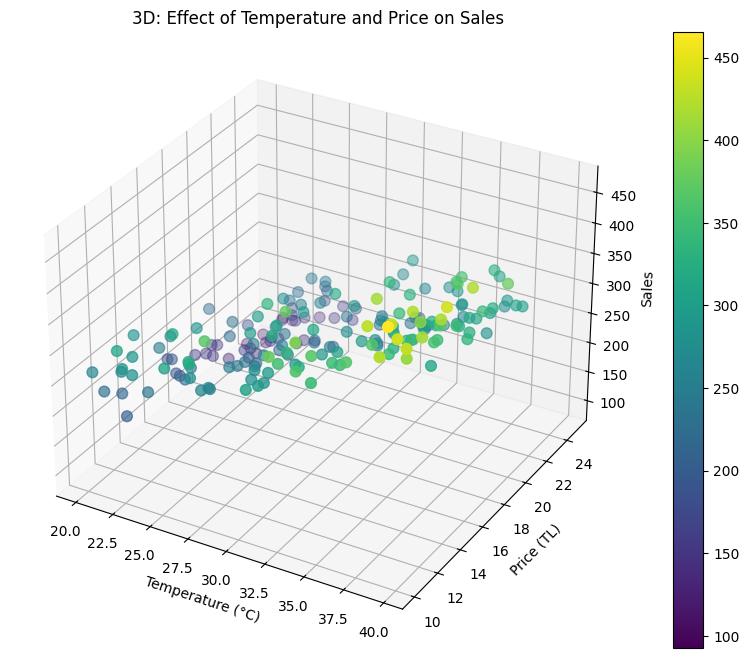

In [6]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

img = ax.scatter(df_multi['Temperature'], df_multi['Price'], df_multi['Sales'], c=df_multi['Sales'], cmap='viridis', s=60)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Price (TL)')
ax.set_zlabel('Sales')
plt.title('3D: Effect of Temperature and Price on Sales')
plt.colorbar(img)
plt.show()

In [7]:
y_pred = multi_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"Model R2 Score: {r2:.2f}")

Model R2 Score: 0.97


In [ ]:
new_data = [[20, 20, 1]] 

prediction = multi_model.predict(new_data)

print(f"Scenario Prediction: {int(prediction[0])} ice creams will be sold.")

Scenario Prediction: 194 ice creams will be sold.


: 